# Neuronale Netze 8: Übungen zur Matrizenmultiplikation
## Trainieren mit einem kleinen Programm

In Colab 07 hast du gelernt:

> Matrizenmultiplikation bedeutet: **Zeile mal Spalte**.

Heute übst du das mit einem kleinen Programm.

Das Programm erstellt automatisch Aufgaben wie:

- `2x3 @ 3x1`
- `2x2 @ 2x2`
- `3x3 @ 3x2`

Du trägst deine Lösung in eine leere Matrix ein.
Dann klickst du auf **Überprüfen**.

Wenn deine Lösung noch nicht stimmt, zeigt dir das Programm den Lösungsweg.
Dafür klickst du auf **Schritt**.

### Ziel

Am Ende kannst du:

1. passende Matrix-Grössen erkennen
2. eine Ergebnis-Matrix richtig ausfüllen
3. den Lösungsweg Schritt für Schritt erklären
4. in Python `@` für Matrizenmultiplikation nutzen


## 1. Bibliotheken laden

Wir nutzen wieder:

- `numpy` für die Rechnungen
- `pandas` für Tabellen
- `matplotlib` für Bilder
- `ipywidgets` für die Knöpfe und Eingabefelder

Führe die nächste Zelle aus.


In [ ]:
#@title Bibliotheken laden { display-mode: "form" }
import random
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown, HTML, clear_output

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    print("ipywidgets wird installiert ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets

# In Google Colab hilft dies manchmal für interaktive Widgets.
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = False
plt.rcParams["font.size"] = 12

pd.set_option("display.max_columns", 20)

## 2. Kurz wiederholen: Welche Grössen passen?

Eine Matrix-Grösse schreibt man so:

$\text{Zeilen} \times \text{Spalten}$

Beispiel:

$2x3 \cdot 3x1$

Die **inneren Zahlen** müssen gleich sein:

$2x\mathbf{3} \cdot \mathbf{3}x1$

Die **äusseren Zahlen** geben die neue Grösse an:

$\mathbf{2}x3 \cdot 3x\mathbf{1} = \mathbf{2}x\mathbf{1}$

Merksatz:

> Innen muss passen. Aussen gibt das Ergebnis.


In [ ]:
#@title Passende Grössen für Matrizen { display-mode: "form" }
shape_examples = [
    ((2, 3), (3, 1)),
    ((2, 2), (2, 2)),
    ((3, 3), (3, 2)),
    ((3, 2), (2, 3)),
    ((4, 2), (2, 1)),
]

rows = []
for left_shape, right_shape in shape_examples:
    result_shape = (left_shape[0], right_shape[1])
    rows.append({
        "Matrix A": f"{left_shape[0]}x{left_shape[1]}",
        "Matrix B": f"{right_shape[0]}x{right_shape[1]}",
        "passt?": "ja",
        "Ergebnis C": f"{result_shape[0]}x{result_shape[1]}",
    })

display(pd.DataFrame(rows))

,Matrix A,Matrix B,passt?,Ergebnis C
0,2x3,3x1,ja,2x1
1,2x2,2x2,ja,2x2
2,3x3,3x2,ja,3x2
3,3x2,2x3,ja,3x3
4,4x2,2x1,ja,4x1


## 3. Bild: Zeile trifft Spalte

Für eine Zelle im Ergebnis nimmst du:

- eine Zeile aus `A`
- eine Spalte aus `B`

Dann rechnest du:

> Zahl mal Zahl, dann alles addieren.


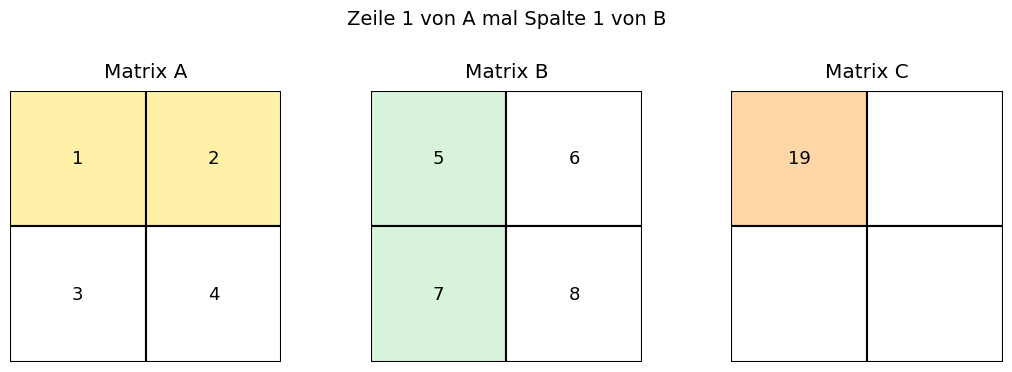

Rechnung oben links: 1 · 5 + 2 · 7 = 19


In [ ]:
#@title Diagramm: Zeile 1 von A mal Spalte 1 von B { display-mode: "form" }
def format_value(value):
    """Gibt Zahlen kurz aus."""
    value = float(value)
    if value.is_integer():
        return str(int(value))
    return f"{value:.2f}"


def draw_matrix(ax, matrix, title="Matrix", highlight_rows=None, highlight_cols=None, highlight_cells=None):
    """Zeichnet eine Matrix als Raster."""
    values = np.array(matrix, dtype=object)
    highlight_rows = set(highlight_rows or [])
    highlight_cols = set(highlight_cols or [])
    highlight_cells = set(highlight_cells or [])

    row_count, column_count = values.shape
    ax.set_xlim(0, column_count)
    ax.set_ylim(0, row_count)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    for row in range(row_count):
        for column in range(column_count):
            facecolor = "white"
            if row in highlight_rows:
                facecolor = "#fff2a8"
            if column in highlight_cols:
                facecolor = "#d8f3dc"
            if (row, column) in highlight_cells:
                facecolor = "#ffd6a5"

            rect = Rectangle((column, row), 1, 1, facecolor=facecolor, edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)
            text = str(values[row, column])
            ax.text(column + 0.5, row + 0.5, text, ha="center", va="center", fontsize=13)

    ax.set_title(title, pad=10)


def plot_step_picture(left_matrix, right_matrix, result_matrix, row_index=0, column_index=0):
    """Zeigt eine Zeile, eine Spalte und eine Ergebniszelle."""
    left_matrix = np.array(left_matrix)
    right_matrix = np.array(right_matrix)
    result_matrix = np.array(result_matrix)

    result_preview = np.full(result_matrix.shape, "", dtype=object)
    result_preview[row_index, column_index] = format_value(result_matrix[row_index, column_index])

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
    draw_matrix(axes[0], left_matrix, title="Matrix A", highlight_rows=[row_index])
    draw_matrix(axes[1], right_matrix, title="Matrix B", highlight_cols=[column_index])
    draw_matrix(axes[2], result_preview, title="Matrix C", highlight_cells=[(row_index, column_index)])

    fig.suptitle(
        f"Zeile {row_index + 1} von A mal Spalte {column_index + 1} von B",
        y=1.03,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


example_A = np.array([[1, 2], [3, 4]])
example_B = np.array([[5, 6], [7, 8]])
example_C = example_A @ example_B
plot_step_picture(example_A, example_B, example_C, row_index=0, column_index=0)
print("Rechnung oben links: 1 · 5 + 2 · 7 = 19")

## 4. Das interaktive Übungsprogramm

So arbeitest du:

1. Klicke auf **Neue Aufgabe**.
2. Schaue dir `A` und `B` an.
3. Trage deine Zahlen in die leere Matrix `C` ein.
4. Klicke auf **Überprüfen**.
5. Wenn es noch nicht stimmt, klicke auf **Schritt**.

Du darfst die Matrix-Grösse auch selbst wählen.
Mit **Automatische Auswahl** erstellt das Programm zufällige Aufgaben.


In [ ]:
#@title Interaktives Übungsprogramm laden { display-mode: "form" }
def matrix_to_dataframe(matrix, row_name="Zeile", column_name="Spalte"):
    """Erstellt eine gut lesbare Tabelle."""
    matrix = np.array(matrix)
    row_labels = [f"{row_name} {index + 1}" for index in range(matrix.shape[0])]
    column_labels = [f"{column_name} {index + 1}" for index in range(matrix.shape[1])]
    return pd.DataFrame(matrix, index=row_labels, columns=column_labels)


def make_table_html(matrix, title):
    """Erstellt HTML für eine Matrix-Tabelle."""
    dataframe = matrix_to_dataframe(matrix)
    table_html = dataframe.to_html(border=1)
    return f"""
    <div style="display:inline-block; margin-right:24px; vertical-align:top;">
        <h4 style="margin-bottom:6px;">{title}</h4>
        {table_html}
    </div>
    """


def parse_entry(text):
    """Liest eine Zahl aus einem Eingabefeld."""
    clean_text = str(text).strip().replace(",", ".")
    if clean_text == "":
        return None
    try:
        value = float(clean_text)
        return value
    except ValueError:
        return None


def build_solution_steps(left_matrix, right_matrix, result_matrix):
    """Erstellt alle Schritte für den Lösungsweg."""
    left_matrix = np.array(left_matrix)
    right_matrix = np.array(right_matrix)
    result_matrix = np.array(result_matrix)

    left_rows, left_columns = left_matrix.shape
    right_rows, right_columns = right_matrix.shape
    result_rows, result_columns = result_matrix.shape

    steps = []
    steps.append({
        "kind": "text",
        "markdown": (
            "### Schritt 1: Grössen prüfen\n\n"
            f"Matrix A hat die Grösse **{left_rows}x{left_columns}**.\n\n"
            f"Matrix B hat die Grösse **{right_rows}x{right_columns}**.\n\n"
            f"Die inneren Zahlen sind **{left_columns}** und **{right_rows}**. Sie passen.\n\n"
            f"Das Ergebnis C hat die Grösse **{result_rows}x{result_columns}**."
        ),
    })

    step_number = 2
    for row in range(result_rows):
        for column in range(result_columns):
            left_values = left_matrix[row, :]
            right_values = right_matrix[:, column]
            products = left_values * right_values
            result_value = result_matrix[row, column]

            calculation = " + ".join(
                f"{format_value(left_values[index])} · {format_value(right_values[index])}"
                for index in range(len(left_values))
            )
            product_text = " + ".join(format_value(product) for product in products)

            steps.append({
                "kind": "cell",
                "row": row,
                "column": column,
                "markdown": (
                    f"### Schritt {step_number}: Zelle C{row + 1}{column + 1}\n\n"
                    f"Wir nehmen **Zeile {row + 1}** von A und **Spalte {column + 1}** von B.\n\n"
                    f"Rechnung:\n\n"
                    f"$ {calculation} = {product_text} = {format_value(result_value)} $\n\n"
                    f"Also kommt **{format_value(result_value)}** in die Zelle C{row + 1}{column + 1}."
                ),
            })
            step_number += 1

    steps.append({
        "kind": "final",
        "markdown": f"### Schritt {step_number}: Ganze Lösung\n\nDas ist die vollständige Matrix C.",
    })
    return steps


class MatrixPracticeApp:
    """Interaktives Übungsprogramm für Matrizenmultiplikation."""

    def __init__(self):
        self.shape_options = [
            ((2, 3), (3, 1)),
            ((2, 2), (2, 2)),
            ((3, 3), (3, 2)),
            ((3, 2), (2, 3)),
            ((2, 4), (4, 2)),
            ((1, 3), (3, 3)),
            ((4, 2), (2, 1)),
        ]

        dropdown_options = [("Automatische Auswahl", "auto")]
        for left_shape, right_shape in self.shape_options:
            label = f"{left_shape[0]}x{left_shape[1]} @ {right_shape[0]}x{right_shape[1]}"
            dropdown_options.append((label, (left_shape, right_shape)))

        self.shape_dropdown = widgets.Dropdown(
            options=dropdown_options,
            value="auto",
            description="Grösse:",
            layout=widgets.Layout(width="310px"),
        )

        self.generate_button = widgets.Button(
            description="Neue Aufgabe",
            button_style="primary",
            layout=widgets.Layout(width="150px"),
        )
        self.check_button = widgets.Button(
            description="Überprüfen",
            button_style="success",
            layout=widgets.Layout(width="150px"),
        )
        self.step_button = widgets.Button(
            description="Schritt",
            button_style="warning",
            disabled=True,
            layout=widgets.Layout(width="150px"),
        )

        self.problem_output = widgets.Output()
        self.input_output = widgets.Output()
        self.feedback_output = widgets.Output()
        self.solution_output = widgets.Output()

        self.left_matrix = None
        self.right_matrix = None
        self.result_matrix = None
        self.entry_widgets = []
        self.steps = []
        self.step_index = 0

        self.generate_button.on_click(self.generate_problem)
        self.check_button.on_click(self.check_solution)
        self.step_button.on_click(self.show_next_step)

    def display(self):
        """Zeigt die ganze Oberfläche an."""
        controls = widgets.HBox([
            self.shape_dropdown,
            self.generate_button,
            self.check_button,
            self.step_button,
        ])
        app = widgets.VBox([
            controls,
            self.problem_output,
            self.input_output,
            self.feedback_output,
            self.solution_output,
        ])
        display(app)
        self.generate_problem(None)

    def choose_shapes(self):
        """Wählt passende Matrix-Grössen."""
        selected_value = self.shape_dropdown.value
        if selected_value == "auto":
            return random.choice(self.shape_options)
        return selected_value

    def generate_problem(self, button):
        """Erstellt eine neue Aufgabe."""
        left_shape, right_shape = self.choose_shapes()

        self.left_matrix = np.random.randint(0, 6, size=left_shape)
        self.right_matrix = np.random.randint(0, 6, size=right_shape)
        self.result_matrix = self.left_matrix @ self.right_matrix

        self.steps = build_solution_steps(self.left_matrix, self.right_matrix, self.result_matrix)
        self.step_index = 0
        self.step_button.disabled = True

        self.show_problem()
        self.show_empty_result_matrix()

        with self.feedback_output:
            clear_output()
            display(Markdown("**Aufgabe bereit.** Trage deine Lösung in Matrix C ein."))

        with self.solution_output:
            clear_output()

    def show_problem(self):
        """Zeigt Matrix A und Matrix B."""
        with self.problem_output:
            clear_output()
            left_rows, left_columns = self.left_matrix.shape
            right_rows, right_columns = self.right_matrix.shape
            result_rows, result_columns = self.result_matrix.shape

            html = f"""
            <h3>Aufgabe</h3>
            <p><b>A</b> hat die Grösse {left_rows}x{left_columns}.</p>
            <p><b>B</b> hat die Grösse {right_rows}x{right_columns}.</p>
            <p><b>C = A @ B</b> hat die Grösse {result_rows}x{result_columns}.</p>
            {make_table_html(self.left_matrix, "Matrix A")}
            {make_table_html(self.right_matrix, "Matrix B")}
            """
            display(HTML(html))

    def show_empty_result_matrix(self):
        """Zeigt die leere Lösungsmatrix."""
        result_rows, result_columns = self.result_matrix.shape
        self.entry_widgets = []
        row_boxes = []

        for row in range(result_rows):
            row_entries = []
            for column in range(result_columns):
                entry = widgets.Text(
                    value="",
                    placeholder=f"C{row + 1}{column + 1}",
                    layout=widgets.Layout(width="80px"),
                )
                self.entry_widgets.append(entry)
                row_entries.append(entry)
            row_boxes.append(widgets.HBox(row_entries))

        with self.input_output:
            clear_output()
            display(Markdown("### Deine Lösung für Matrix C"))
            display(widgets.VBox(row_boxes))

    def read_answer_matrix(self):
        """Liest die Zahlen aus der Lösungsmatrix."""
        result_rows, result_columns = self.result_matrix.shape
        answer = np.zeros((result_rows, result_columns), dtype=float)
        missing_cells = []

        for index, entry in enumerate(self.entry_widgets):
            row = index // result_columns
            column = index % result_columns
            value = parse_entry(entry.value)
            if value is None:
                missing_cells.append((row, column))
            else:
                answer[row, column] = value

        return answer, missing_cells

    def check_solution(self, button):
        """Prüft die Lösung der lernenden Person."""
        answer, missing_cells = self.read_answer_matrix()

        with self.feedback_output:
            clear_output()
            if missing_cells:
                display(Markdown(
                    "**Noch nicht prüfen.** Es fehlen Zahlen oder eine Eingabe ist keine Zahl. "
                    "Fülle zuerst alle Felder in Matrix C aus."
                ))
                self.step_button.disabled = True
                return

            if np.allclose(answer, self.result_matrix):
                display(Markdown(
                    "✅ **Richtig.** Sehr gut. Deine Matrix C stimmt."
                ))
                self.step_button.disabled = True
                with self.solution_output:
                    clear_output()
                return

            display(Markdown(
                "❌ **Noch nicht ganz.** Eine oder mehrere Zahlen stimmen noch nicht.\n\n"
                "Klicke auf **Schritt**, um den Lösungsweg langsam zu sehen."
            ))
            self.step_index = 0
            self.step_button.disabled = False

        with self.solution_output:
            clear_output()

    def show_next_step(self, button):
        """Zeigt den nächsten Schritt des Lösungswegs."""
        if self.step_index >= len(self.steps):
            self.step_button.disabled = True
            with self.solution_output:
                display(Markdown("**Ende.** Alle Schritte wurden angezeigt."))
            return

        step = self.steps[self.step_index]
        self.step_index += 1

        with self.solution_output:
            display(Markdown(step["markdown"]))

            if step["kind"] == "cell":
                plot_step_picture(
                    self.left_matrix,
                    self.right_matrix,
                    self.result_matrix,
                    row_index=step["row"],
                    column_index=step["column"],
                )

            if step["kind"] == "final":
                display(matrix_to_dataframe(self.result_matrix).style.format("{:.0f}"))

            if self.step_index >= len(self.steps):
                self.step_button.disabled = True
                display(Markdown("**Das war der letzte Schritt.** Vergleiche jetzt mit deiner Matrix C."))

## 5. Übungsprogramm starten

Führe die nächste Zelle aus.

Danach erscheint das Übungsprogramm.


In [ ]:
#@title Interaktives Übungsprogramm starten { display-mode: "form" }
practice_app = MatrixPracticeApp()
practice_app.display()

## 6. Hilfe für das Kopfrechnen

Du musst nicht raten.

Für jede Zelle gilt:

1. Wähle die passende Zeile aus `A`.
2. Wähle die passende Spalte aus `B`.
3. Multipliziere die Zahlen paarweise.
4. Addiere alle Produkte.

Beispiel:

$[1, 2, 3] \cdot \begin{bmatrix}4 \\ 5 \\ 6\end{bmatrix}$

$1 \cdot 4 + 2 \cdot 5 + 3 \cdot 6 = 4 + 10 + 18 = 32$


## 7. Mini-Aufträge

Bearbeite mehrere Aufgaben im Übungsprogramm.

1. Löse zuerst drei Aufgaben mit **2x3 @ 3x1**.
2. Löse danach zwei Aufgaben mit **2x2 @ 2x2**.
3. Löse danach eine Aufgabe mit **3x3 @ 3x2**.
4. Schreibe bei einer falschen Lösung den ersten Fehler auf.
5. Erkläre einer anderen Person den Merksatz: **Innen muss passen. Aussen gibt das Ergebnis.**

Bleib ruhig, wenn ein Ergebnis falsch ist.
Der Button **Schritt** hilft dir beim Lernen. (Nach den Klicken der Schaltfläche "Schritt" kurz warten. Erklärungsbild wird aufgebaut!)


## 8. Merksätze

- Eine Matrix ist eine Tabelle mit Zahlen.
- Die Grösse ist: Zeilen x Spalten.
- Bei der Matrizenmultiplikation gilt: Zeile mal Spalte.
- In Python bedeutet `@`: Matrizenmultiplikation.
- Die inneren Zahlen müssen gleich sein.
- Die äusseren Zahlen geben die Grösse der Ergebnis-Matrix an.

Copyright 2026 [Markus Ineichen](mailto:markus.ineichen1@sluz.ch)

Code licence: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)
